# Modeling - K-Means Clustering pada Fitur TSFEL

Dokumen ini adalah tahap **Modeling** pada kerangka CRISP-DM. Berbeda
dari dokumen Data Understanding (satu kecamatan, satu mahasiswa), tahap
ini memakai **data ekstraksi fitur TSFEL dari banyak daerah** yang
dikumpulkan bersama oleh teman teman kelas. Tujuannya adalah mengelompokkan
daerah daerah tersebut berdasarkan karakter deret waktu polutannya
memakai **K-Means**, sekaligus menilai seberapa layak data ini
dikelompokkan.

## 1. Pertanyaan yang Dijawab dan Rencana Analisis

| No | Pertanyaan | Dijawab pada |
|----|------------|--------------|
| 1 | Berapa jumlah cluster (k) terbaik pada K-Means? | Bagian 5 dan 6.2 |
| 2 | Bagaimana hasil reduksi dimensi PCA menjadi 37 komponen (PC1 sampai PC37)? | Bagian 6.1 |
| 3 | Dari PC1 sampai PC37, berapa k terbaik dan seberapa baik hasil cluster-nya? | Bagian 6.2 dan 6.3 |
| 4 | Seberapa baik data ini dapat dikelompokkan? | Bagian 6.3, 8, 10, dan 11 |
| 5 | Apakah hasilnya sama jika memakai 68 fitur asli tanpa PCA? | Bagian 8 |
| 6 | Bagaimana mengerjakannya di KNIME? | Bagian 7 (PCA 37) dan 9 (68 fitur) |

Setiap analisis Python di dokumen ini diikuti langsung oleh satu bagian
khusus untuk implementasi di **KNIME**, lengkap dengan langkah langkah
node dan tempat untuk menempelkan hasil eksekusinya.

Semua sel kode di bawah benar benar dieksekusi saat buku dibangun, jadi
seluruh angka yang tampil berasal dari data, bukan tabel statis.

## 2. Data yang Dipakai

Tiga file CSV, satu per polutan, masing masing berisi hasil ekstraksi
68 fitur TSFEL untuk 37 daerah (satu baris per mahasiswa/daerah).

| Kolom | Isi |
|-------|-----|
| `id` | Nomor baris pada sumber data. **Bukan fitur**, dan nilainya berbeda antar file, sehingga tidak boleh dipakai untuk menggabungkan file. |
| `nama`, `daerah` | Identitas baris (label). Bukan fitur numerik. |
| 68 kolom sisanya | Fitur TSFEL (statistical, temporal, spectral, fractal), lihat Bagian 12 dokumen Data Understanding. |

Karena `id` tidak konsisten antar file dan penulisan nama sedikit berbeda
(misalnya `A.Choiril` dan `A. Choiril`), analisis dilakukan **terpisah
per polutan**. Menggabungkan ketiga polutan menjadi 204 fitur per daerah
mungkin dilakukan pada tahap lanjutan, dengan menormalkan nama terlebih
dahulu.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
POLUTAN = ["NO2", "CO", "SO2"]
META = ["id", "nama", "daerah"]
K_RANGE = range(2, 11)   # k = 2 sampai 10
N_KOMPONEN = 37          # jumlah komponen PCA yang diminta
pd.set_option("display.width", 200)


def cari_file(nama_file):
    # mencoba beberapa lokasi umum agar sel ini aman dijalankan dari
    # folder notebook maupun dari root proyek
    for basis in ["", "data/", "../data/", "../", "../../data/"]:
        if os.path.exists(basis + nama_file):
            return basis + nama_file
    raise FileNotFoundError(nama_file)


raw = {p: pd.read_csv(cari_file(f"ekstraksi_fitur_{p.lower()}.csv")) for p in POLUTAN}

pd.DataFrame({
    "Polutan": POLUTAN,
    "Baris (daerah)": [raw[p].shape[0] for p in POLUTAN],
    "Kolom total": [raw[p].shape[1] for p in POLUTAN],
    "Kolom fitur": [raw[p].shape[1] - len(META) for p in POLUTAN],
    "Nilai hilang": [int(raw[p].isna().sum().sum()) for p in POLUTAN],
})

,Polutan,Baris (daerah),Kolom total,Kolom fitur,Nilai hilang
0,NO2,37,71,68,0
1,CO,37,71,68,0
2,SO2,37,71,68,0


## 3. Pemeriksaan Kualitas Data Sebelum Clustering

K-Means berbasis jarak Euclidean, sehingga satu baris yang skalanya
menyimpang jauh dapat mendominasi seluruh hasil. Karena data berasal dari
banyak orang yang mengekstrak sendiri sendiri, perlu dicek dulu apakah
semua baris sebanding. Dua pemeriksaan dipakai:

- **Rasio skala** = `calc_max` baris tersebut dibagi median `calc_max`
  seluruh baris. Nilai mendekati 1 berarti setara. Nilai ribuan atau lebih
  menandakan satuan atau skala yang berbeda (mis. hasil konversi satuan).
- **Rasio panjang deret** = `ecdf_percentile_count` baris tersebut dibagi
  mediannya. Fitur ini (bersama `calc_centroid`, `distance`, `auc`,
  `abs_energy`) membesar seiring jumlah titik data, sehingga rasio ini
  dipakai sebagai perkiraan kasar panjang deret. Deret sepanjang 366 hari
  akan memberi rasio sekitar 1.

Baris ditandai untuk dikeluarkan pada Skenario B bila rasio skala > 100
atau rasio panjang > 3. Baris dengan deret jauh lebih pendek (rasio < 0.7)
hanya dicatat, tidak dikeluarkan.

In [2]:
def cek_konsistensi(df):
    X = df.drop(columns=META)
    rasio_skala = X["calc_max"].abs() / X["calc_max"].abs().median()
    rasio_panjang = X["ecdf_percentile_count"] / X["ecdf_percentile_count"].median()
    tabel = df[["nama", "daerah"]].copy()
    tabel["rasio_skala"] = rasio_skala
    tabel["rasio_panjang"] = rasio_panjang
    tabel["dikeluarkan_B"] = (rasio_skala > 100) | (rasio_panjang > 3)
    return tabel


konsistensi = {p: cek_konsistensi(raw[p]) for p in POLUTAN}
keluarkan = {
    p: konsistensi[p].loc[konsistensi[p]["dikeluarkan_B"], "nama"].tolist()
    for p in POLUTAN
}

catatan = []
for p in POLUTAN:
    t = konsistensi[p]
    t = t[t["dikeluarkan_B"] | (t["rasio_panjang"] < 0.7)].copy()
    t.insert(0, "Polutan", p)
    catatan.append(t)
catatan = pd.concat(catatan, ignore_index=True)
catatan["Status"] = np.where(catatan["dikeluarkan_B"], "dikeluarkan di Skenario B", "hanya dicatat")
catatan[["Polutan", "nama", "daerah", "rasio_skala", "rasio_panjang", "Status"]].round(2)

,Polutan,nama,daerah,rasio_skala,rasio_panjang,Status
0,NO2,Robbaniyah Umdatun Ni'mah,"Cerme, Gresik",1.86,0.63,hanya dicatat
1,NO2,Marshella Aulia Putri,"Kec. Kalianget, Sumenep",0.50,0.53,hanya dicatat
2,NO2,Dewi Geizya,"Kamal, Banyuajuh",1165623.73,1.00,dikeluarkan di Skenario B
3,CO,Marshella Aulia Putri,"Kec. Kalianget, Sumenep",0.93,0.55,hanya dicatat
4,CO,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",1.00,14.07,dikeluarkan di Skenario B
5,CO,Dewi Geizya,"Kamal, Banyuajuh",56544.64,1.00,dikeluarkan di Skenario B
6,SO2,Marshella Aulia Putri,"Kec. Kalianget, Sumenep",0.77,0.65,hanya dicatat
7,SO2,Muhammad Zaidan Nabil Rafi,"Kamal, Bangkalan",1.73,14.07,dikeluarkan di Skenario B
8,SO2,Dewi Geizya,"Kamal, Banyuajuh",92418.60,1.00,dikeluarkan di Skenario B


Temuan pada tabel di atas perlu dibaca dengan hati hati:

1. **Dewi Geizya (Kamal, Banyuajuh)** memiliki nilai fitur berskala
   puluhan ribu sampai jutaan kali lebih besar pada ketiga polutan
   (misalnya rata rata NO2 sekitar 33.6, sedangkan baris lain sekitar
   0.00003). Ini hampir pasti akibat perbedaan satuan atau kesalahan
   ekstraksi, bukan kondisi udara yang sebenarnya.
2. **Muhammad Zaidan Nabil Rafi (Kamal, Bangkalan)** pada CO dan SO2
   memiliki deret sekitar 14 kali lebih panjang dari baris lain, tanda
   bahwa data yang diekstrak berbeda cakupan atau resolusi waktu (bukan
   365 sampai 366 hari). Pada NO2 barisnya normal.
3. **Marshella Aulia Putri dan Robbaniyah Umdatun Ni'mah** memiliki deret
   yang lebih pendek (sekitar separuh sampai tiga perempat panjang normal).
   Ini masih mungkin wajar (mis. lebih banyak hari tanpa data valid),
   sehingga hanya dicatat.

> **Saran tindak lanjut.** Dua temuan pertama sebaiknya dikonfirmasi ke
> pemilik datanya dan diekstrak ulang (periksa satuan, dan pastikan sinyal
> sudah di-reindex ke 366 hari seperti pada Bagian 12 Data Understanding).
> Sampai itu dilakukan, analisis dijalankan dalam dua skenario:
>
> - **Skenario A** memakai data **apa adanya** (37 baris). Ini yang
>   sesuai permintaan awal (PCA 37 komponen dari 37 daerah).
> - **Skenario B** memakai data **tanpa baris yang ditandai** di atas
>   (36 baris untuk NO2, 35 baris untuk CO dan SO2), sebagai uji
>   sensitivitas (Bagian 10).

## 4. Persiapan Data: Fitur Konstan dan Standardisasi

**Fitur konstan dibuang.** Fitur yang nilainya sama pada semua baris
(varians nol) tidak membawa informasi dan membuat standardisasi
(pembagian dengan simpangan baku) tidak terdefinisi. Karena itu, dari
"68 fitur" yang benar benar dipakai adalah 66 (NO2, SO2) dan 65 (CO),
seperti terlihat pada tabel di bawah.

**Standardisasi z-score wajib.** Skala antar fitur TSFEL sangat berbeda
(misalnya `abs_energy` pada orde 1e-6, sedangkan `zero_cross` berupa
bilangan bulat ratusan). Tanpa standardisasi, fitur berskala besar akan
mendominasi jarak Euclidean dan PCA. Setiap fitur diubah menjadi
`(x - rata rata) / simpangan baku` sehingga bermean 0 dan bervarians 1.
Kolom `id` tidak ikut karena bukan fitur.

In [3]:
def siapkan(df, keluarkan_nama=()):
    d = df[~df["nama"].isin(keluarkan_nama)].reset_index(drop=True)
    X = d.drop(columns=META)
    konstan = X.columns[X.std(ddof=0) == 0].tolist()
    X = X.drop(columns=konstan)
    Z = StandardScaler().fit_transform(X)
    return d[META], X, Z, konstan


A = {p: siapkan(raw[p]) for p in POLUTAN}   # Skenario A: data apa adanya

pd.DataFrame({
    "Polutan": POLUTAN,
    "Baris": [A[p][2].shape[0] for p in POLUTAN],
    "Fitur dipakai": [A[p][2].shape[1] for p in POLUTAN],
    "Fitur konstan dibuang": [", ".join(A[p][3]) for p in POLUTAN],
})

,Polutan,Baris,Fitur dipakai,Fitur konstan dibuang
0,NO2,37,66,"human_range_energy, spectral_roll_on"
1,CO,37,65,"human_range_energy, spectral_roll_on, zero_cross"
2,SO2,37,66,"human_range_energy, spectral_roll_on"


## 5. Cara Menentukan Jumlah Cluster (k) Terbaik

K-Means tidak menentukan k sendiri, sehingga k dicari dengan
membandingkan beberapa nilai k (2 sampai 10) memakai empat ukuran. Untuk
tiap k, K-Means dijalankan dengan `n_init=50` (50 inisialisasi acak, dipilih
yang terbaik) dan `random_state=42` agar hasilnya dapat direproduksi.

| Ukuran | Cara membaca | k terbaik |
|--------|--------------|-----------|
| **WSS** (inertia, metode elbow) | Jumlah kuadrat jarak titik ke pusat clusternya. Selalu turun saat k naik, jadi dicari "siku" tempat penurunannya mulai melandai. | Siku kurva |
| **Silhouette** | Rata rata seberapa dekat titik ke clusternya dibanding cluster tetangga terdekat. Rentang -1 sampai 1. | Nilai tertinggi |
| **Calinski-Harabasz** | Rasio sebaran antar cluster terhadap sebaran dalam cluster. | Nilai tertinggi |
| **Davies-Bouldin** | Rata rata kemiripan tiap cluster dengan cluster terdekatnya. | Nilai terendah |

Selain itu dihitung dua ukuran pendukung:

- **Cluster terkecil**: jumlah anggota cluster paling kecil. Nilai 1
  berarti ada cluster yang hanya berisi satu daerah, yang pada praktiknya
  adalah pencilan, bukan kelompok.
- **Stabilitas (ARI)**: rata rata *Adjusted Rand Index* antara hasil pada
  data penuh dan hasil pada 30 subsampel acak berisi 80% baris. Nilai 1
  berarti pengelompokan tidak berubah saat sebagian data dibuang. Untuk
  solusi yang memuat cluster satu anggota, nilai ini kurang bermakna
  (bila titik itu ikut terbuang, strukturnya hilang).

Aturan keputusan yang dipakai: **k terbaik adalah k dengan silhouette
tertinggi**, lalu hasilnya dicek terhadap ukuran cluster terkecil dan
stabilitas. Kategori nilai silhouette mengikuti Kaufman dan Rousseeuw
(1990):

| Silhouette rata rata | Tafsir |
|:--------------------:|--------|
| 0.71 - 1.00 | Struktur cluster kuat |
| 0.51 - 0.70 | Struktur cukup wajar |
| 0.26 - 0.50 | Struktur lemah, mungkin buatan |
| <= 0.25 | Tidak ada struktur cluster yang berarti |

In [4]:
def stabilitas_bootstrap(M, labels, k, n_ulang=30, frac=0.8):
    rng = np.random.default_rng(SEED + k)
    n = M.shape[0]
    skor = []
    for b in range(n_ulang):
        idx = rng.choice(n, size=int(frac * n), replace=False)
        km_b = KMeans(n_clusters=k, n_init=5, random_state=b).fit(M[idx])
        skor.append(adjusted_rand_score(labels[idx], km_b.labels_))
    return float(np.mean(skor))


def evaluasi_k(M, k_range=K_RANGE):
    baris = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=50, random_state=SEED).fit(M)
        lab = km.labels_
        baris.append({
            "k": k,
            "WSS": km.inertia_,
            "Silhouette": silhouette_score(M, lab),
            "Calinski-Harabasz": calinski_harabasz_score(M, lab),
            "Davies-Bouldin": davies_bouldin_score(M, lab),
            "Cluster terkecil": int(np.bincount(lab).min()),
            "Stabilitas (ARI)": stabilitas_bootstrap(M, lab, k),
        })
    t = pd.DataFrame(baris).set_index("k")
    t["Turun WSS (%)"] = -t["WSS"].pct_change() * 100
    return t


def gambar_evaluasi(tabel, judul):
    k_best = tabel["Silhouette"].idxmax()
    fig, ax = plt.subplots(1, 4, figsize=(16, 3.4))
    panel = [
        ("WSS", "WSS (cari siku)"),
        ("Silhouette", "Silhouette (tertinggi terbaik)"),
        ("Calinski-Harabasz", "Calinski-Harabasz (tertinggi terbaik)"),
        ("Davies-Bouldin", "Davies-Bouldin (terendah terbaik)"),
    ]
    for a, (kolom, judul_panel) in zip(ax, panel):
        a.plot(tabel.index, tabel[kolom], marker="o")
        a.axvline(k_best, color="tab:red", ls="--", lw=1)
        a.set_title(judul_panel, fontsize=10)
        a.set_xlabel("k")
    fig.suptitle(f"{judul}  |  garis merah = k terbaik menurut silhouette (k={k_best})", y=1.04)
    fig.tight_layout()
    plt.show()
    return k_best


def tafsir_silhouette(s):
    if s > 0.70:
        return "kuat"
    if s > 0.50:
        return "cukup wajar"
    if s > 0.25:
        return "lemah"
    return "tidak ada struktur berarti"


def tabel_ringkasan(eval_d, best_d, matriks_d, meta_d):
    baris = []
    for p in POLUTAN:
        k = best_d[p]
        r = eval_d[p].loc[k]
        lab = KMeans(n_clusters=k, n_init=50, random_state=SEED).fit_predict(matriks_d[p])
        ukuran = np.bincount(lab)
        kecil = np.argmin(ukuran)
        anggota_kecil = meta_d[p]["nama"][lab == kecil].tolist() if ukuran[kecil] <= 3 else "-"
        baris.append({
            "Polutan": p,
            "k terbaik": k,
            "Silhouette": r["Silhouette"],
            "Tafsir": tafsir_silhouette(r["Silhouette"]),
            "Ukuran cluster": sorted(ukuran, reverse=True),
            "Anggota cluster terkecil (jika <= 3)": anggota_kecil,
            "Stabilitas (ARI)": r["Stabilitas (ARI)"],
        })
    return pd.DataFrame(baris).set_index("Polutan")

## 6. Analisis 1: PCA 37 Komponen lalu K-Means (Skenario A)

### 6.1 Reduksi Dimensi menjadi 37 Komponen (PC1 sampai PC37)

Data z-score tiap polutan (37 baris x 65 atau 66 fitur) diproyeksikan
dengan PCA menjadi 37 komponen utama.

Ada satu fakta matematis yang menentukan cara membaca seluruh hasil
berikutnya. Jumlah komponen PCA tidak bisa melebihi
`min(jumlah baris, jumlah fitur)`, yaitu `min(37, 66) = 37`. Jadi 37
adalah **batas maksimum**, bukan angka pemampatan. Lebih jauh lagi,
karena data sudah dipusatkan (mean 0), 37 baris hanya membentang ruang
berdimensi paling banyak **36** (rank = n - 1). Akibatnya:

- **PC37 memiliki varians nol** (nilainya hanya sisa galat numerik,
  sekitar 1e-33; lihat kolom `Varians PC37` di bawah).
- **PC1 sampai PC37 menyimpan 100% varians data.** Tidak ada informasi
  yang dibuang; PCA di sini hanya memutar sumbu koordinat.

In [5]:
def jalankan_pca(Z, n_komponen=N_KOMPONEN):
    n_komponen = min(n_komponen, *Z.shape)
    pca = PCA(n_components=n_komponen, random_state=SEED).fit(Z)
    return pca, pca.transform(Z)


PCA_A = {p: jalankan_pca(A[p][2]) for p in POLUTAN}

ringkas = []
for p in POLUTAN:
    pca, P = PCA_A[p]
    kum = np.cumsum(pca.explained_variance_ratio_)
    ringkas.append({
        "Polutan": p,
        "Baris x Fitur": f"{A[p][2].shape[0]} x {A[p][2].shape[1]}",
        "Jumlah komponen": P.shape[1],
        "Rank data": int(np.linalg.matrix_rank(A[p][2])),
        "PC1 (%)": kum[0] * 100,
        "PC1-2 (%)": kum[1] * 100,
        "PC1-5 (%)": kum[4] * 100,
        "PC1-10 (%)": kum[9] * 100,
        "Komponen utk 90%": int(np.argmax(kum >= 0.90) + 1),
        "Komponen utk 95%": int(np.argmax(kum >= 0.95) + 1),
        "PC1-37 (%)": kum[-1] * 100,
        "Varians PC37": f"{pca.explained_variance_[-1]:.1e}",
    })
pd.DataFrame(ringkas).set_index("Polutan").round(4)

,Baris x Fitur,Jumlah komponen,Rank data,PC1 (%),PC1-2 (%),PC1-5 (%),PC1-10 (%),Komponen utk 90%,Komponen utk 95%,PC1-37 (%),Varians PC37
Polutan,,,,,,,,,,,
NO2,37 x 66,37,36,45.8151,68.5793,86.2886,95.6579,7,10,100.0,1.8e-31
CO,37 x 65,37,36,53.9550,77.6264,90.4670,97.0289,5,8,100.0,1.9e-31
SO2,37 x 66,37,36,53.0483,77.4551,91.4009,97.6745,5,8,100.0,2.4e-31


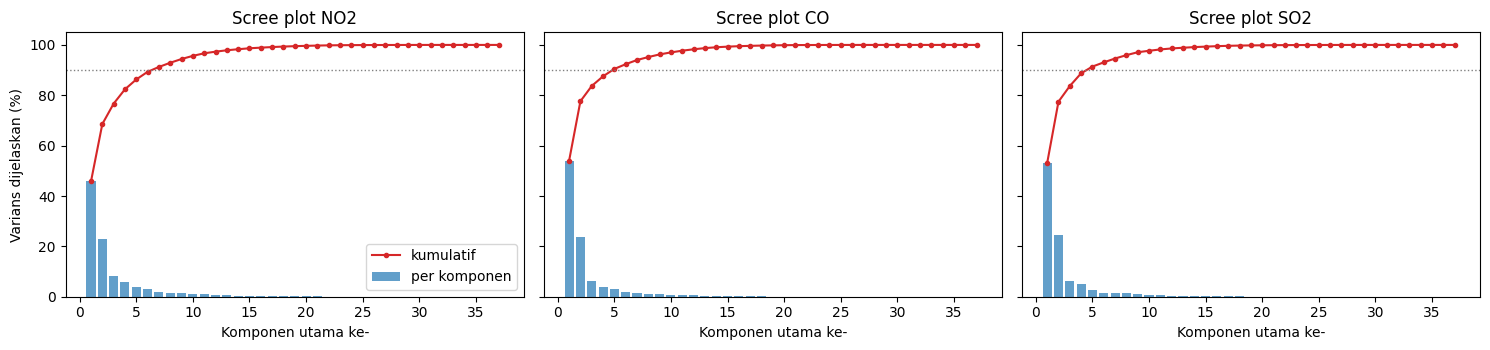

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for a, p in zip(ax, POLUTAN):
    ev = PCA_A[p][0].explained_variance_ratio_ * 100
    a.bar(range(1, len(ev) + 1), ev, alpha=0.7, label="per komponen")
    a.plot(range(1, len(ev) + 1), np.cumsum(ev), color="tab:red", marker=".", label="kumulatif")
    a.axhline(90, color="gray", ls=":", lw=1)
    a.set_title(f"Scree plot {p}")
    a.set_xlabel("Komponen utama ke-")
ax[0].set_ylabel("Varians dijelaskan (%)")
ax[0].legend()
fig.tight_layout()
plt.show()

Sebagian besar informasi terkumpul pada beberapa komponen pertama
(sekitar 96 sampai 98 persen varians pada 10 komponen pertama), sedangkan
komponen komponen belakang nyaris tidak membawa informasi. Artinya 37
komponen sebenarnya jauh lebih banyak dari yang dibutuhkan; ini
diperhatikan lagi pada uji jumlah PC di Bagian 6.3.

### 6.2 Menentukan Jumlah Cluster Terbaik pada PC1 sampai PC37

K-Means dijalankan pada seluruh 37 komponen (PC1 sampai PC37) untuk
k = 2 sampai 10, lalu dievaluasi memakai empat ukuran pada Bagian 5.

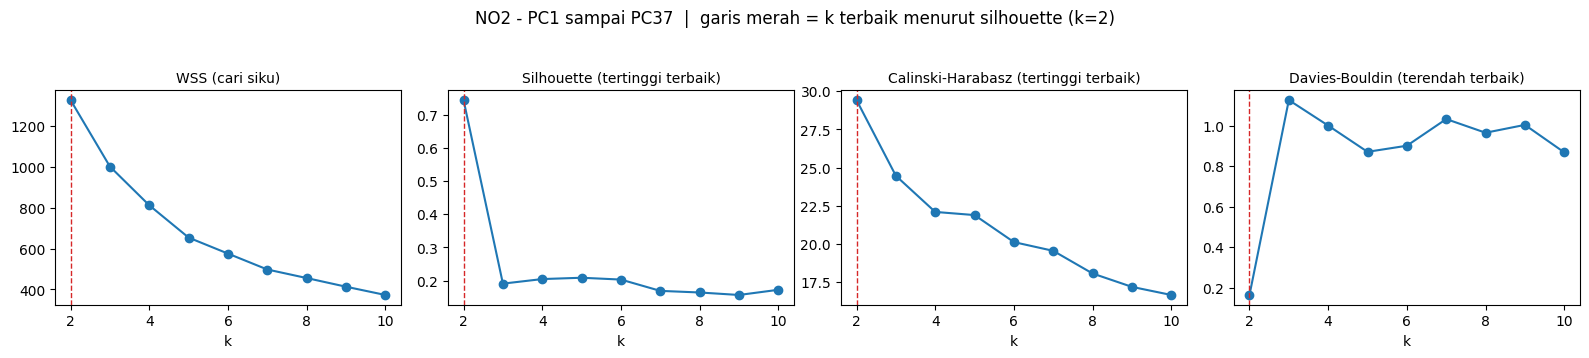

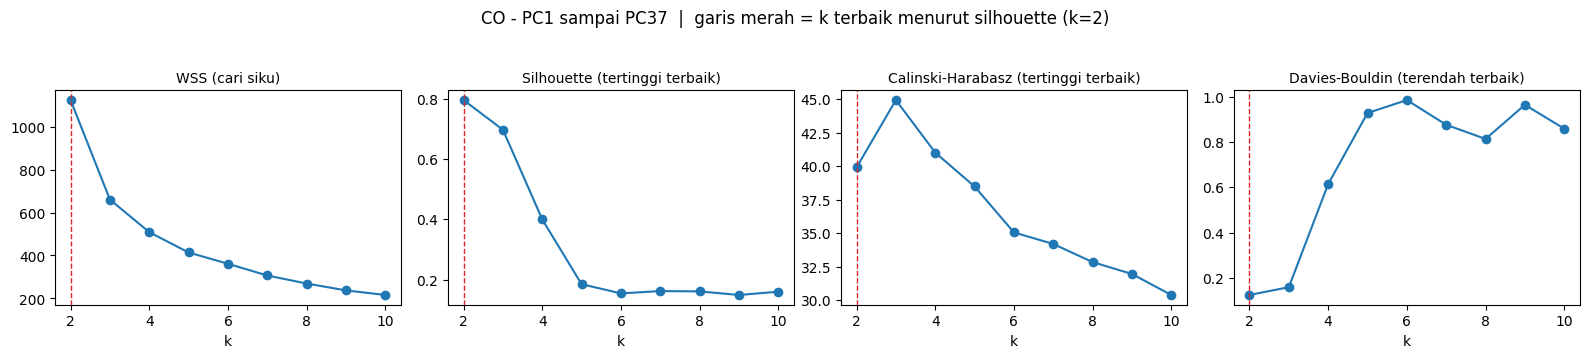

KeyboardInterrupt: 

In [7]:
EVAL_A1, BEST_A1 = {}, {}
for p in POLUTAN:
    EVAL_A1[p] = evaluasi_k(PCA_A[p][1])
    BEST_A1[p] = gambar_evaluasi(EVAL_A1[p], f"{p} - PC1 sampai PC37")

In [ ]:
for p in POLUTAN:
    print(f"\n=== {p} (PC1-PC37) ===")
    print(EVAL_A1[p].round(3).to_string())

Tabel acuan berikut merangkum silhouette per k untuk ketiga polutan.
Simpan sebagai pembanding hasil KNIME pada Bagian 7.

In [ ]:
pd.DataFrame({p: EVAL_A1[p]["Silhouette"] for p in POLUTAN}).round(3)

### 6.3 Seberapa Baik Data Ini Dikelompokkan?

In [ ]:
tabel_ringkasan(EVAL_A1, BEST_A1, {p: PCA_A[p][1] for p in POLUTAN}, {p: A[p][0] for p in POLUTAN})

**Jawaban singkat untuk Skenario A.** k terbaik menurut silhouette adalah
**k = 2 pada ketiga polutan**, dengan silhouette sekitar 0.75 sampai 0.80
yang secara angka tergolong "kuat". **Angka ini menyesatkan.** Tabel di
atas menunjukkan ukuran cluster `[36, 1]`: K-Means hanya memisahkan
satu daerah, yaitu Dewi Geizya, dari 36 daerah lainnya. Silhouette tinggi
di sini semata mencerminkan jauhnya satu titik pencilan dari semua titik
lain, bukan adanya dua kelompok alami. Beberapa bukti pendukung:

- Kolom "Cluster terkecil" pada tabel per k di Bagian 6.2 bernilai 1 untuk
  **semua** k dari 2 sampai 10. Selalu ada daerah yang berdiri sendiri.
- Pada plot PC1 vs PC2 di bawah, satu titik tampak terpisah jauh dari
  awan titik lainnya (dan pada CO serta SO2 ada satu titik lagi yang
  menjauh pada PC2, yaitu Muhammad Zaidan Nabil Rafi).
- Pencilan ini berasal dari masalah konsistensi data pada Bagian 3,
  bukan dari perbedaan kualitas udara antar daerah.

In [ ]:
def gambar_scatter(pca_dict, k_dict, judul):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, p in zip(ax, POLUTAN):
        pca, P = pca_dict[p]
        lab = KMeans(n_clusters=k_dict[p], n_init=50, random_state=SEED).fit_predict(P)
        a.scatter(P[:, 0], P[:, 1], c=lab, cmap="tab10", s=45, edgecolor="k", linewidth=0.4)
        a.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
        a.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
        a.set_title(f"{p}, k={k_dict[p]}")
    fig.suptitle(judul, y=1.02)
    fig.tight_layout()
    plt.show()


gambar_scatter(PCA_A, BEST_A1, "Skenario A: posisi tiap daerah pada PC1 vs PC2 (warna = cluster)")

**Berapa baik hasil PC1 sampai PC37, dan apakah perlu 37 komponen?**
Sel berikut memakai hanya PC1 sampai PC*m* (untuk beberapa nilai *m*),
mencari k terbaik, lalu melaporkan silhouette dan ukuran cluster
terkecilnya. Ini menunjukkan apakah hasil bergantung pada jumlah komponen
yang dipakai.

In [ ]:
def k_terbaik_dan_skor(M):
    skor, kecil = {}, {}
    for k in K_RANGE:
        lab = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit_predict(M)
        skor[k] = silhouette_score(M, lab)
        kecil[k] = int(np.bincount(lab).min())
    k_b = max(skor, key=skor.get)
    return k_b, skor[k_b], kecil[k_b]


JUMLAH_PC = [2, 3, 5, 10, 15, 20, 30, 37]
sweep = {}
for m in JUMLAH_PC:
    baris = {}
    for p in POLUTAN:
        k_b, s_b, kc = k_terbaik_dan_skor(PCA_A[p][1][:, :m])
        baris[p] = f"k={k_b}, sil={s_b:.3f}, terkecil={kc}"
    sweep[f"PC1-PC{m}"] = baris
pd.DataFrame(sweep).T

Dua hal terbaca dari tabel tersebut. Pertama, hasilnya konsisten:
k terbaik tetap 2 berapa pun jumlah komponen yang dipakai, dan cluster
terkecil tetap berisi satu daerah. Kedua, silhouette justru **lebih
tinggi** saat komponen sedikit dan menurun saat komponen ditambah sampai
37. Kenaikan itu bukan tanda cluster yang lebih baik: cluster yang
terbentuk tetap satu daerah pencilan. Penurunan silhouette saat
komponen ditambah konsisten dengan gejala umum pada dimensi tinggi,
yaitu jarak antar titik makin seragam dan komponen belakang (yang nyaris
hanya berisi derau, lihat scree plot) ikut menambah jarak. Kesimpulannya, memakai
seluruh 37 komponen tidak menambah kualitas pengelompokan; ia hanya
memberi hasil yang setara dengan memakai semua fitur (dibuktikan pada
Bagian 8).

## 7. Implementasi di KNIME: PCA 37 Komponen + K-Means

Bagian ini adalah tempat mengerjakan Bagian 6 memakai **KNIME Analytics
Platform**, agar hasil Python dapat dibandingkan langsung dengan KNIME.
Nama node mengacu pada KNIME 5.x; letak atau nama opsi pada versi lain
bisa sedikit berbeda, jadi gunakan kolom pencarian pada *Node Repository*
untuk menemukan node yang dimaksud.

### 7.1 Gambaran Alur Kerja

```text
CSV Reader
   -> Column Filter                (buang id)
   -> Low Variance Filter          (buang fitur konstan)
   -> Normalizer                   (z-score)
   -> PCA                          (37 dimensi)
   -> Counting Loop Start          (9 putaran)
   -> Math Formula (Variable)      (k = putaran + 2)
   -> k-Means                      (k dari flow variable)
   -> Silhouette Coefficient
   -> Loop End                     (Add iteration column)
   -> Table View                   (baca silhouette tiap k)

Setelah k terbaik dipilih (cabang terpisah dari titik keluaran PCA):
PCA -> k-Means (k tetap) -> Color Manager -> Scatter Plot
                         -> GroupBy (hitung ukuran cluster)
                         -> Sorter -> CSV Writer
```

Alur ini dibuat **satu kali untuk NO2**, lalu disalin untuk CO dan SO2
dengan mengganti berkas pada CSV Reader.

### 7.2 Langkah Demi Langkah

**Langkah 1. Baca data (CSV Reader).**
Tambahkan node **CSV Reader**, arahkan ke `ekstraksi_fitur_no2.csv`.
Pastikan opsi *Has column header* aktif dan pemisah kolom adalah koma.
Klik kanan node, pilih *Output table* dan periksa: **37 baris x 71
kolom**; `id` bertipe angka bulat, `nama` dan `daerah` bertipe string, 68
kolom sisanya bertipe angka desimal (Number/double).

**Langkah 2. Buang kolom `id` (Column Filter).**
Sambungkan **Column Filter**, pada bagian *Exclude* pindahkan `id`.
`id` adalah nomor baris, bukan fitur; bila tertinggal, ia ikut
distandardisasi dan ikut dihitung dalam jarak K-Means, sehingga hasilnya
salah. Kolom `nama` dan `daerah` boleh tetap ada karena bertipe string
dan otomatis diabaikan oleh node numerik; keduanya berguna untuk
membaca hasil akhir.

**Langkah 3. Buang fitur konstan (Low Variance Filter).**
Sambungkan **Low Variance Filter**, atur *Variance upper bound* = `0`
dan pilih semua kolom numerik. Node ini membuang fitur yang nilainya sama
di semua baris. Hasil yang diharapkan mengikuti Bagian 4: **66 kolom
numerik untuk NO2 dan SO2, 65 untuk CO** (ditambah `nama` dan `daerah`).

**Langkah 4. Standardisasi (Normalizer).**
Sambungkan **Normalizer**, pilih mode **Z-Score Normalization
(Gaussian)** dan sertakan seluruh kolom numerik. Setelah ini, tiap
kolom bermean 0 dan simpangan baku 1. KNIME memakai simpangan baku
sampel (dibagi n - 1), sedangkan `StandardScaler` Python dibagi n. Selisihnya
konstan untuk semua kolom sehingga **tidak mengubah hasil clustering
maupun silhouette**; hanya nilai varians mentah yang berbeda sedikit.

**Langkah 5. Reduksi dimensi (PCA).**
Sambungkan node **PCA** (Node Repository: *Analytics > Mining > PCA*).
Atur jumlah dimensi tujuan menjadi `37` (kolom pengaturan *Target
dimensions* atau *Dimensions to reduce to*) dan aktifkan opsi
*Replace original data columns* agar hanya kolom komponen yang
tersisa. Node PCA tidak menstandardisasi sendiri, itulah sebabnya
Langkah 4 wajib dilakukan sebelumnya.

Hal yang perlu diperhatikan pada hasil PCA:

- Kolom keluaran diberi nama **`PCA dimension 0`, `PCA dimension 1`,
  dan seterusnya, dimulai dari 0**. Jadi `PCA dimension 0` setara dengan
  PC1 di Python. Periksa nama kolom sebenarnya pada *Output table*.
- Tanda (plus atau minus) suatu komponen boleh berbeda dari Python.
  Itu wajar dan tidak memengaruhi jarak antar titik.
- Komponen terakhir (`PCA dimension 36`) hampir berisi nol karena data
  hanya berdimensi 36, sama seperti PC37 di Bagian 6.1. Bila node
  memberi peringatan atau galat pada 37 dimensi, turunkan menjadi 36;
  hasil clustering tidak berubah karena komponen ke-37 tidak membawa
  informasi.
- Untuk memeriksa proporsi varians, sambungkan **Statistics** ke keluaran
  data PCA dan bandingkan *proporsi* (varians tiap komponen dibagi total)
  dengan kolom `PC1 (%)` dan seterusnya pada tabel Bagian 6.1. Jangan
  membandingkan nilai varians mentah karena beda penyebut (n vs n - 1).

**Langkah 6. Buat perulangan untuk k = 2 sampai 10.**
Sambungkan **Counting Loop Start** dan atur *Number of loops* = `9`
(variabel `currentIteration` dimulai dari 0). Sambungkan
**Math Formula (Variable)** dengan ekspresi
`$${IcurrentIteration}$$ + 2` dan namai variabel keluarannya `k`; pastikan
tipenya integer (aktifkan opsi konversi ke integer bila tersedia).
Bila perulangan terasa rumit, alternatifnya adalah menyalin node
k-Means dan Silhouette Coefficient sebanyak 9 kali dan mengisi k = 2
sampai 10 secara manual.

**Langkah 7. Jalankan K-Means (k-Means).**
Sambungkan node **k-Means** (*Analytics > Mining > Clustering*) dan
atur:

| Pengaturan | Nilai |
|------------|-------|
| Number of clusters | Hubungkan ke flow variable `k` (klik ikon variabel di samping isian, atau lewat tab *Flow Variables*) |
| Initialization | *Random initialization* dengan *Use static random seed* dicentang (mis. 42) |
| Max. number of iterations | 99 (bawaan) |
| Columns to use | Mode *Wildcard/Regex*, pola `PCA dimension*`, agar hanya kolom PCA yang dipakai |

Keluaran pertama berisi seluruh kolom masukan ditambah kolom **`Cluster`**
(nilai `cluster_0`, `cluster_1`, dan seterusnya).

**Langkah 8. Hitung silhouette (Silhouette Coefficient).**
Sambungkan **Silhouette Coefficient**, pilih kolom `Cluster` sebagai
kolom cluster dan kolom `PCA dimension*` sebagai kolom data (jarak
Euclidean). Node ini mengeluarkan koefisien silhouette per cluster dan
nilai keseluruhan; yang dibandingkan dengan Python adalah **nilai
keseluruhan**. Bila node ini tidak tersedia pada instalasi Anda, pasang
lewat *File > Install KNIME Extensions*, atau hitung silhouette dengan
node **Python Script** memakai `silhouette_score` dari scikit-learn.

**Langkah 9. Kumpulkan hasil semua k (Loop End).**
Sambungkan **Loop End** dan aktifkan *Add iteration column*. Kolom
iterasi dimulai dari 0, sehingga **k = iterasi + 2**. Buka *Output
table* dan catat silhouette keseluruhan tiap k pada tabel isian Bagian 7.3.

KNIME tidak memberikan WSS, Calinski-Harabasz, maupun Davies-Bouldin
secara langsung pada node k-Means. Untuk KNIME, cukup gunakan
**silhouette ditambah ukuran cluster** sebagai dasar memilih k;
ukuran lain sudah dihitung pada Python (Bagian 6.2).

**Langkah 10. Lihat ukuran cluster dan sebaran (untuk k terbaik).**
Buat cabang baru dari keluaran PCA: node **k-Means** dengan `k` diisi
langsung (tanpa loop) sesuai k terbaik, lalu:

1. **GroupBy**: kelompokkan berdasarkan `Cluster` dengan agregasi
   *Count*. Hasilnya harus sama dengan kolom "Ukuran cluster" pada tabel
   ringkasan Bagian 6.3 (mis. 36 dan 1 pada Skenario A).
2. **Color Manager** (warna berdasar `Cluster`), lalu **Scatter Plot**
   dengan sumbu X = `PCA dimension 0` dan sumbu Y = `PCA dimension 1`.
   Bentuk sebarannya harus mirip plot PC1 vs PC2 pada Bagian 6.3.

**Langkah 11. Ekspor keanggotaan cluster.**
Sambungkan **Sorter** (urut `Cluster`) lalu **CSV Writer** dan simpan
sebagai `hasil_knime_no2_pca37.csv` (kolom `nama`, `daerah`, `Cluster`).

**Langkah 12. Ulangi untuk CO dan SO2.**
Salin seluruh cabang, ganti berkas pada CSV Reader ke
`ekstraksi_fitur_co.csv` dan `ekstraksi_fitur_so2.csv`.

### 7.3 Catatan agar Hasil KNIME Cocok dengan Python

- **K-Means KNIME hanya satu kali inisialisasi**, sedangkan Python di sini
  memilih yang terbaik dari 50 inisialisasi. Pada k besar, KNIME bisa
  berhenti di solusi lokal yang berbeda. Cocokkan pada k kecil (2 sampai 5)
  atau ganti *static random seed* beberapa kali dan ambil hasil yang
  paling sering muncul.
- **Nomor cluster boleh tertukar** (`cluster_0` di KNIME belum tentu 0 di
  Python). Yang dibandingkan adalah *ukuran cluster* dan *siapa yang
  sekelompok*, bukan nomornya.
- Pada Skenario A, hasil yang benar adalah satu cluster berisi satu
  daerah saja (Dewi Geizya). Bila KNIME menghasilkan pembagian lain
  pada k = 2, periksa lagi Langkah 2 (`id` sudah dibuang?) dan
  Langkah 4 (sudah dinormalisasi sebelum PCA?).

### 7.4 Tempat Hasil Implementasi KNIME (Isi Setelah Dijalankan)

Tempelkan tangkapan layar alur kerja dan hasilnya di sini, lalu isi tabel
pembanding. Hapus tanda komentar `<!-- -->` pada baris gambar setelah
berkasnya tersedia di folder buku.

<!-- ![Workflow KNIME PCA 37 + K-Means](knime_workflow_pca37.png) -->
<!-- ![Silhouette per k di KNIME (NO2)](knime_silhouette_no2_pca37.png) -->
<!-- ![Scatter PCA dimension 0 vs 1 (NO2)](knime_scatter_no2_pca37.png) -->

Tabel pembanding silhouette (isi kolom KNIME dari *Output table* Loop End;
kolom Python diambil dari tabel acuan Bagian 6.2):

| Polutan | k | Silhouette Python | Silhouette KNIME | Ukuran cluster KNIME | Cocok? |
|---------|:-:|:-----------------:|:----------------:|:--------------------:|:------:|
| NO2 | 2 | 0.745 | | | |
| CO | 2 | 0.795 | | | |
| SO2 | 2 | 0.789 | | | |

## 8. Analisis 2: K-Means pada Fitur Asli (68 Fitur) Tanpa PCA

Analisis yang sama diulang pada data z-score **tanpa PCA**, yaitu memakai
seluruh fitur asli (68 kolom, atau 66 dan 65 kolom setelah fitur konstan
dibuang pada Bagian 4). Cara evaluasinya identik dengan Bagian 6.2.

In [ ]:
EVAL_A2, BEST_A2 = {}, {}
for p in POLUTAN:
    EVAL_A2[p] = evaluasi_k(A[p][2])
    BEST_A2[p] = gambar_evaluasi(EVAL_A2[p], f"{p} - fitur asli (z-score)")

In [ ]:
for p in POLUTAN:
    print(f"\n=== {p} (fitur asli, z-score) ===")
    print(EVAL_A2[p].round(3).to_string())

In [ ]:
tabel_ringkasan(EVAL_A2, BEST_A2, {p: A[p][2] for p in POLUTAN}, {p: A[p][0] for p in POLUTAN})

### 8.1 Mengapa Hasilnya Sama dengan PCA 37?

Hasil pada fitur asli hampir identik dengan hasil PC1 sampai PC37. Ini
bukan kebetulan, melainkan konsekuensi matematis:

1. Karena data dipusatkan, 37 baris hanya membentang ruang berdimensi
   36. Seluruh baris berada di ruang yang sama dengan yang dibentuk oleh
   komponen komponen utama PCA.
2. PCA tanpa *whitening* hanyalah **rotasi** ke sumbu sumbu baru. Bila
   semua komponen yang membawa varians dipertahankan (di sini PC1 sampai
   PC36, dan PC37 bervarians nol), **jarak Euclidean antar baris tidak
   berubah**.
3. Fungsi tujuan K-Means (WSS) sepenuhnya ditentukan oleh jarak Euclidean
   antar titik. Jarak sama berarti solusi optimum yang sama.

Sel berikut membuktikannya secara numerik.

In [ ]:
baris = []
for p in POLUTAN:
    Z = A[p][2]
    P = PCA_A[p][1]
    k = BEST_A2[p]
    lab_z = KMeans(n_clusters=k, n_init=50, random_state=SEED).fit_predict(Z)
    lab_p = KMeans(n_clusters=k, n_init=50, random_state=SEED).fit_predict(P)
    baris.append({
        "Polutan": p,
        "Selisih maks. jarak antar baris (Z vs PCA)": np.abs(pdist(Z) - pdist(P)).max(),
        "k terbaik (PCA 37)": BEST_A1[p],
        "k terbaik (fitur asli)": BEST_A2[p],
        "ARI label pada k terbaik": adjusted_rand_score(lab_z, lab_p),
        "Selisih silhouette maks. (k=2..10)": (EVAL_A1[p]["Silhouette"] - EVAL_A2[p]["Silhouette"]).abs().max(),
    })
pd.DataFrame(baris).set_index("Polutan")

Selisih jarak berada pada orde galat pembulatan (sekitar 1e-14 atau
lebih kecil), sehingga kedua ruang koordinat dapat dianggap sama. Pada
k kecil, silhouette kedua analisis sama persis. Perbedaan kecil yang
dapat muncul pada k besar (pada eksekusi ini: WSS dan silhouette CO pada
k = 10) **bukan** berasal
dari PCA, melainkan dari sifat acak K-Means: galat pembulatan yang
sangat kecil mengubah pemilihan pusat awal, sehingga K-Means dapat
berakhir di solusi lokal yang sedikit berbeda. Fakta ini sendiri
menandakan solusi pada k besar tidak stabil.

**Implikasinya.** Pada data ini (37 baris), meminta PCA sebanyak 37
komponen tidak menghasilkan reduksi yang berarti, sehingga hasilnya sama
dengan memakai semua fitur. PCA baru mengubah hasil bila jumlah
komponen dipangkas (mis. cukup 90 sampai 95 persen varians, yaitu sekitar
5 sampai 10 komponen pada Skenario A; lihat tabel Bagian 6.1) atau bila
memakai *whitening*.

## 9. Implementasi di KNIME: K-Means pada Fitur Asli (Tanpa PCA)

Alurnya sama dengan Bagian 7, hanya **tanpa node PCA**. K-Means langsung
memakai seluruh kolom numerik yang sudah dinormalisasi.

### 9.1 Gambaran Alur Kerja

```text
CSV Reader
   -> Column Filter                (buang id)
   -> Low Variance Filter          (buang fitur konstan)
   -> Normalizer                   (z-score)
   -> Counting Loop Start          (9 putaran)
   -> Math Formula (Variable)      (k = putaran + 2)
   -> k-Means                      (semua kolom numerik)
   -> Silhouette Coefficient
   -> Loop End                     (Add iteration column)
   -> Table View
```

### 9.2 Langkah Demi Langkah

Langkah 1 sampai 4 **sama persis** dengan Bagian 7.2 (CSV Reader,
Column Filter untuk membuang `id`, Low Variance Filter, Normalizer
z-score). Kemudian:

**Langkah 5. Lewati PCA.** Sambungkan keluaran Normalizer langsung ke
Counting Loop Start.

**Langkah 6. Perulangan k.** Sama dengan Langkah 6 pada Bagian 7.2
(Counting Loop Start dengan 9 putaran, lalu Math Formula (Variable)
`$${IcurrentIteration}$$ + 2` menjadi variabel `k`).

**Langkah 7. k-Means.** Pengaturannya sama dengan Bagian 7.2 kecuali
*Columns to use*: pilih **seluruh kolom numerik hasil normalisasi** (66
kolom untuk NO2 dan SO2, 65 untuk CO). Pastikan `id` tidak ikut.

**Langkah 8 sampai 12.** Silhouette Coefficient, Loop End, pemilihan k
terbaik, Scatter Plot, GroupBy, dan ekspor CSV dikerjakan seperti pada
Bagian 7.2. Perbedaannya hanya pada Scatter Plot: karena tidak ada
kolom PCA, tambahkan node **PCA** terpisah pada cabang visualisasi
(2 dimensi sudah cukup) atau gunakan dua fitur pilihan sebagai sumbu.
Simpan hasil ekspor sebagai `hasil_knime_no2_fitur_asli.csv`.

### 9.3 Membuktikan Kesamaan dengan Versi PCA (di KNIME)

Untuk membuktikan bahwa versi 68 fitur dan versi PCA 37 menghasilkan
pengelompokan yang sama, cocokkan keanggotaan cluster keduanya:

1. Baca `hasil_knime_no2_pca37.csv` dan `hasil_knime_no2_fitur_asli.csv`
   memakai dua node **CSV Reader**.
2. Sambungkan keduanya ke node **Joiner** dengan kunci gabung `nama`
   (bila ada nama ganda, tambahkan `daerah` sebagai kunci kedua). Ubah
   nama kolom `Cluster` menjadi `Cluster_PCA` dan `Cluster_Asli` (lewat
   tab *Column Selection* Joiner atau node **Column Rename**).
3. Sambungkan **Crosstab** (atau **Pivoting**) dengan `Cluster_PCA` sebagai
   baris dan `Cluster_Asli` sebagai kolom.
4. Hasil yang benar: **setiap baris dan setiap kolom hanya memiliki satu
   sel bernilai tidak nol**. Nomor cluster boleh tertukar, tetapi jumlah
   anggotanya harus sama.

### 9.4 Tempat Hasil Implementasi KNIME (Isi Setelah Dijalankan)

<!-- ![Workflow KNIME 68 fitur](knime_workflow_fitur_asli.png) -->
<!-- ![Silhouette per k di KNIME (68 fitur, NO2)](knime_silhouette_no2_fitur_asli.png) -->
<!-- ![Crosstab PCA vs fitur asli](knime_crosstab_pca_vs_asli.png) -->

| Polutan | k | Silhouette Python | Silhouette KNIME (68 fitur) | Crosstab diagonal murni? |
|---------|:-:|:-----------------:|:---------------------------:|:------------------------:|
| NO2 | 2 | 0.745 | | |
| CO | 2 | 0.795 | | |
| SO2 | 2 | 0.789 | | |

## 10. Analisis Sensitivitas: Skenario B (Tanpa Baris Tidak Konsisten)

Karena hasil Skenario A didominasi oleh baris yang bermasalah, analisis
diulang setelah baris yang ditandai pada Bagian 3 dikeluarkan: Dewi
Geizya pada ketiga polutan, serta Muhammad Zaidan Nabil Rafi pada CO dan
SO2. Jumlah baris menjadi 36 (NO2) dan 35 (CO, SO2), sehingga jumlah
komponen PCA maksimum turun menjadi 36 dan 35 (batas 37 tidak lagi
tercapai). Karena hasil PCA dengan semua komponen sama dengan fitur asli
(Bagian 8.1), K-Means langsung dijalankan pada data z-score; PCA dipakai
hanya untuk plot.

In [ ]:
B = {p: siapkan(raw[p], keluarkan[p]) for p in POLUTAN}
PCA_B = {p: jalankan_pca(B[p][2]) for p in POLUTAN}

EVAL_B, BEST_B = {}, {}
for p in POLUTAN:
    EVAL_B[p] = evaluasi_k(B[p][2])
    BEST_B[p] = gambar_evaluasi(EVAL_B[p], f"{p} - Skenario B (n={B[p][2].shape[0]}, {B[p][2].shape[1]} fitur)")

In [ ]:
for p in POLUTAN:
    print(f"\n=== {p} (Skenario B) ===")
    print(EVAL_B[p].round(3).to_string())

In [ ]:
tabel_ringkasan(EVAL_B, BEST_B, {p: B[p][2] for p in POLUTAN}, {p: B[p][0] for p in POLUTAN})

In [ ]:
gambar_scatter(PCA_B, BEST_B, "Skenario B: posisi tiap daerah pada PC1 vs PC2 (warna = cluster)")

Berikut anggota tiap cluster pada k terbaik. Cluster besar tidak
diuraikan; daftar lengkap disimpan ke `hasil_kmeans_python_skenario_B.csv`
untuk dibandingkan dengan hasil KNIME.

In [ ]:
baris, semua = [], []
for p in POLUTAN:
    meta, X, Z, _ = B[p]
    k = BEST_B[p]
    lab = KMeans(n_clusters=k, n_init=50, random_state=SEED).fit_predict(Z)
    tmp = meta.copy()
    tmp.insert(0, "Polutan", p)
    tmp["k"] = k
    tmp["cluster"] = lab
    semua.append(tmp)
    for c in sorted(set(lab)):
        anggota = meta["daerah"][lab == c].tolist()
        baris.append({
            "Polutan": p,
            "Cluster": c,
            "Jumlah": len(anggota),
            "Daerah": "; ".join(anggota) if len(anggota) <= 9 else f"({len(anggota)} daerah, lihat CSV)",
        })

pd.concat(semua, ignore_index=True).to_csv("hasil_kmeans_python_skenario_B.csv", index=False)
pd.DataFrame(baris).set_index(["Polutan", "Cluster"])

**Cara membaca hasil Skenario B.**

- **NO2**: k terbaik = 2 dengan silhouette sekitar 0.33 (tergolong
  lemah), ukuran cluster 30 dan 6. Untuk k >= 3 silhouette turun ke
  kisaran 0.15 sampai 0.18, yaitu tidak ada struktur berarti.
- **CO**: k terbaik = 2 dengan silhouette sekitar 0.49 (batas atas
  "lemah"), tetapi cluster kecilnya hanya berisi dua daerah, Marshella
  Aulia Putri (Kalianget, Sumenep) dan Robbaniyah Umdatun Ni'mah (Cerme,
  Gresik). Keduanya adalah dua daerah dengan deret data paling pendek pada CO
  (rasio panjang 0.55 untuk Marshella pada tabel Bagian 3, dan sekitar
  0.72 untuk Robbaniyah, sedikit di atas ambang pencatatan), sehingga
  pemisahan ini patut dicurigai sebagai efek jumlah data valid, bukan
  perbedaan kualitas udara. Untuk k >= 3 silhouette hanya sekitar 0.22
  ke bawah.
- **SO2**: k terbaik = 3 dengan silhouette sekitar 0.25 (tepat di batas
  "tidak ada struktur berarti"), ukuran cluster 23, 9, dan 3.
- Plot PC1 vs PC2 memperlihatkan sebaran yang cenderung kontinu tanpa
  celah antar kelompok yang jelas.
- Ukuran lain tidak selalu sepakat dengan silhouette: pada SO2,
  Calinski-Harabasz tertinggi di k = 6 dan Davies-Bouldin terendah di
  k = 7; pada NO2, Davies-Bouldin terendah di k = 10 (lihat tabel per k
  di atas). Tidak ada satu k yang unggul secara meyakinkan.
- Stabilitas (ARI) pada k terbaik berkisar 0.60 sampai 0.73: keanggotaan
  cluster cukup berubah bila 20 persen data dibuang, jadi hasilnya
  bersifat indikatif saja.
- Sebagai pengamatan yang perlu diuji lebih lanjut (bukan kesimpulan):
  lima dari enam anggota cluster kecil NO2 (Manyar, Gresik Kota, Cerme,
  Menganti, Asemrowo) berada di kawasan Gresik dan Surabaya yang padat
  industri, ditambah Kamal (Bangkalan). Dengan silhouette hanya 0.33,
  dugaan ini hanya layak dijadikan hipotesis untuk analisis berikutnya.

### 10.1 Catatan KNIME untuk Skenario B

Tambahkan node **Row Filter** tepat setelah **CSV Reader** (sebelum Column
Filter) pada alur Bagian 7 atau 9:

| Polutan | Baris yang dikeluarkan (kolom `nama`) |
|---------|----------------------------------------|
| NO2 | `Dewi Geizya` |
| CO | `Dewi Geizya` dan `Muhammad Zaidan Nabil Rafi` |
| SO2 | `Dewi Geizya` dan `Muhammad Zaidan Nabil Rafi` |

Pada dialog Row Filter, pilih **Exclude rows by attribute value**, kolom
`nama`, dan aktifkan *use pattern matching* dengan nama persis sebagai
pola. Untuk CO dan SO2 gunakan dua Row Filter berurutan (satu per nama).
Setelah itu periksa jumlah baris: **36 untuk NO2 dan 35 untuk CO dan
SO2**. Pada node PCA (bila dipakai) atur dimensi tujuan menjadi 36 (NO2)
atau 35 (CO, SO2). Sisa langkahnya sama dengan Bagian 7.2.



<!-- ![Workflow KNIME Skenario B](knime_workflow_skenario_b.png) -->

## 11. Kesimpulan

In [ ]:
def teks_hasil(eval_d, best_d, p):
    k = best_d[p]
    return f"k={k}, silhouette={eval_d[p].loc[k, 'Silhouette']:.3f}"


pd.DataFrame({
    "A: PCA 37 komponen": {p: teks_hasil(EVAL_A1, BEST_A1, p) for p in POLUTAN},
    "A: 68 fitur asli": {p: teks_hasil(EVAL_A2, BEST_A2, p) for p in POLUTAN},
    "B: tanpa baris tidak konsisten": {p: teks_hasil(EVAL_B, BEST_B, p) for p in POLUTAN},
})

**Jumlah cluster terbaik.** Pada data apa adanya (Skenario A) k terbaik
adalah 2 untuk NO2, CO, dan SO2, baik memakai PC1 sampai PC37 maupun 68
fitur asli. Namun cluster kedua hanya berisi satu daerah (Dewi Geizya)
yang skala datanya menyimpang jutaan kali lipat, sehingga k = 2 di sini
mendeteksi **data yang bermasalah, bukan kelompok daerah**. Setelah baris
bermasalah dikeluarkan (Skenario B), k terbaik adalah 2 untuk NO2 dan CO,
dan 3 untuk SO2.

**PCA 37 komponen versus 68 fitur.** Untuk 37 baris, PC1 sampai PC37
menyimpan 100% varians (PC37 bervarians nol), sehingga hasilnya
setara dengan memakai semua fitur. PCA 37 komponen tidak memperbaiki
maupun memperburuk kualitas cluster; ia hanya memutar sumbu.

**Seberapa baik data ini dikelompokkan.** Kurang baik. Silhouette pada
Skenario A tampak tinggi (0.75 sampai 0.80) hanya karena satu pencilan.
Pada Skenario B silhouette turun ke 0.33 (NO2), 0.49 (CO, dengan cluster
kecil berisi dua daerah berderet pendek), dan 0.25 (SO2): struktur lemah
sampai hampir tidak ada, dan stabilitas antar subsampel sedang saja.
Secara umum, daerah daerah pada data ini membentuk sebaran yang kontinu
dan bukan kelompok yang tegas, sehingga label cluster sebaiknya
diperlakukan sebagai ringkasan deskriptif, bukan pembagian alami.

**Tindak lanjut yang disarankan.**

1. Ekstrak ulang data Dewi Geizya (periksa satuan) dan Muhammad Zaidan
   Nabil Rafi pada CO dan SO2 (pastikan sinyal di-reindex ke 366 hari
   seperti pada Data Understanding), lalu ulangi analisis ini.
2. Fitur yang bergantung pada panjang deret (`abs_energy`, `auc`,
   `distance`, `calc_centroid`, `ecdf_percentile_count`, dan sejenisnya)
   membuat deret pendek tampak berbeda. Pertimbangkan
   menyeragamkan panjang deret, atau mengecualikan fitur tersebut,
   sebelum clustering.
3. Coba PCA dengan komponen yang lebih sedikit (90 sampai 95 persen
   varians) atau *whitening*, karena 37 komponen tidak mengurangi
   dimensi sama sekali pada data ini.
4. Gabungkan ketiga polutan (204 fitur per daerah) setelah nama daerah
   dinormalkan, dan bandingkan dengan algoritma lain yang tahan
   pencilan (mis. hierarchical clustering atau DBSCAN).